## Spotify Viral Modeling

### 1. Setup & Data Loading

#### 1.1 Setup

In [5]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [6]:
# !ls /content/drive/MyDrive | grep "spotify_tracks_cleaned.csv"

In [7]:
import pandas as pd 
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/processed/spotify_tracks_cleaned.csv"
COLAB_DATA_PATH = "/content/drive/MyDrive/spotify_tracks_cleaned.csv"

#### 1.2 Data Loading

In [8]:
df = pd.read_csv(DATA_PATH)

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Columns: 128 entries, duration_ms to track_genre_world-music
dtypes: bool(114), float64(9), int64(5)
memory usage: 24.6 MB


,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,viral
count,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,0.243599
std,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,0.429255
min,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,0.000000
50%,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,0.000000
75%,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,0.000000
max,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,1.000000


### 2. Feature & Target Preparation

#### 2.1 Create Features

In [9]:
X = df.drop(columns=['viral'], axis=1)

#### 2.2 Create Target

In [10]:
y = df['viral']

#### 2.3 Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape, X_test.shape

((91199, 127), (22800, 127))

### 3. Modeling 

#### 3.1 Baseline Model - Decision Tree Classifier

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Training Accuracy: 0.9935
Testing Accuracy: 0.7728
Precision: 0.5282
Recall: 0.5227
F1 Score: 0.5254


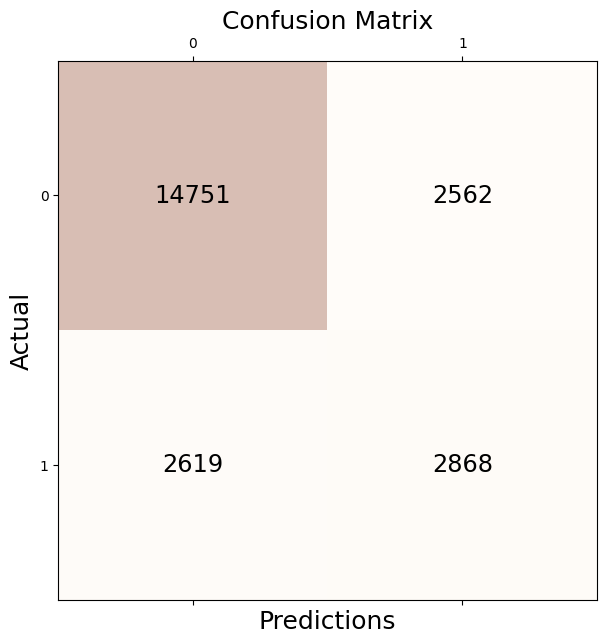

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     17313
           1       0.53      0.52      0.53      5487

    accuracy                           0.77     22800
   macro avg       0.69      0.69      0.69     22800
weighted avg       0.77      0.77      0.77     22800



In [15]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")

conf_matrix = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred))

In [16]:
print("Accuracy: ", (conf_matrix[0,0]+conf_matrix[1,1])/(conf_matrix[0,0]+conf_matrix[1,1]+conf_matrix[0,1]+conf_matrix[1,0]) )
print("Precision of non-viral: ", (conf_matrix[0,0])/(conf_matrix[0,0]+conf_matrix[0,1]) )
print("Recall of non-viral: ", (conf_matrix[0,0])/(conf_matrix[0,0]+conf_matrix[1,0]) )

Accuracy:  0.7727631578947368
Precision of non-viral:  0.85201871426096
Recall of non-viral:  0.8492227979274611


#### 3.2 Baseline Model - Random Forrest Model 

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
# Create Gaussian Classifier
rf = RandomForestClassifier(n_estimators=1000)

In [19]:
# Train the model using the training sets y_pred=clf.predict(X_test)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

Training Accuracy: 0.9935
Testing Accuracy: 0.8430
Precision: 0.7653
Recall: 0.5015
F1 Score: 0.6060


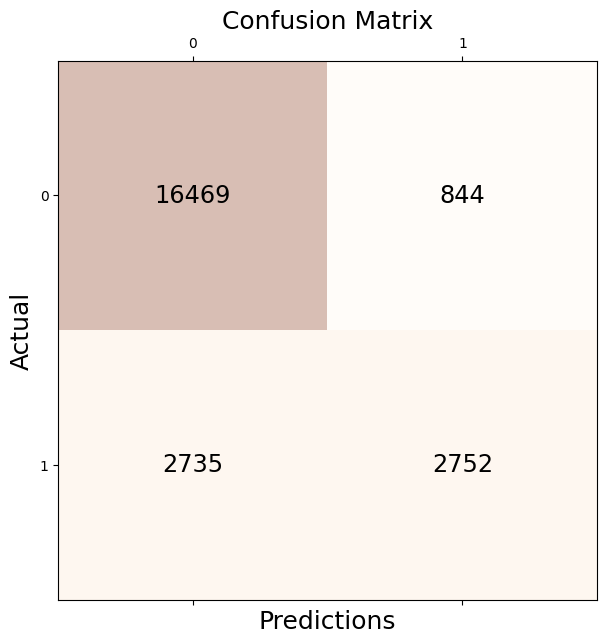

              precision    recall  f1-score   support

           0       0.86      0.95      0.90     17313
           1       0.77      0.50      0.61      5487

    accuracy                           0.84     22800
   macro avg       0.81      0.73      0.75     22800
weighted avg       0.84      0.84      0.83     22800



In [20]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_rf):.4f}")

conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_rf, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_rf.shape[0]):
    for j in range(conf_matrix_rf.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_rf[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_rf))


In [21]:
print("Accuracy: ", (conf_matrix_rf[0,0]+conf_matrix_rf[1,1])/(conf_matrix_rf[0,0]+conf_matrix_rf[1,1]+conf_matrix_rf[0,1]+conf_matrix_rf[1,0]) )
print("Precision of non-viral: ", (conf_matrix_rf[0,0])/(conf_matrix_rf[0,0]+conf_matrix_rf[0,1]) )
print("Recall of non-viral: ", (conf_matrix_rf[0,0])/(conf_matrix_rf[0,0]+conf_matrix_rf[1,0]) )

Accuracy:  0.8430263157894737
Precision of non-viral:  0.951250505400566
Recall of non-viral:  0.8575817538012914


#### 3.3 Baseline Model - XGBoost Classifier

In [22]:
import xgboost as xgb
from xgboost import XGBClassifier

In [23]:
xgb = XGBClassifier(n_estimators=1000)

In [24]:
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Training Accuracy: 0.9815
Testing Accuracy: 0.8507
Precision: 0.7272
Recall: 0.6076
F1 Score: 0.6620


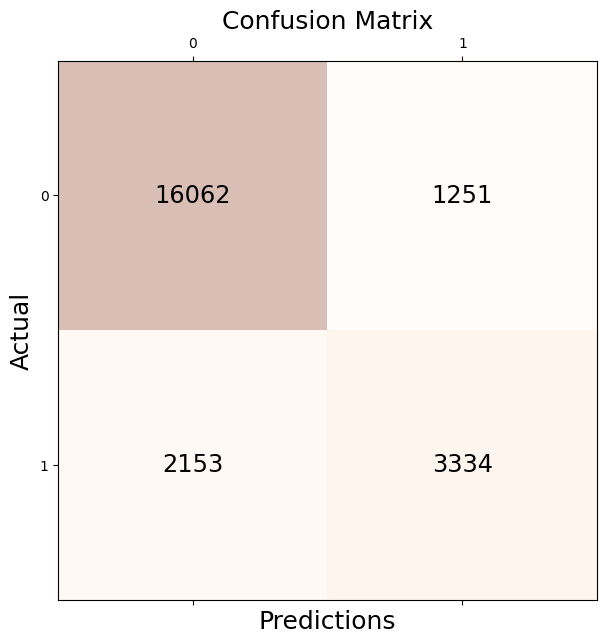

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     17313
           1       0.73      0.61      0.66      5487

    accuracy                           0.85     22800
   macro avg       0.80      0.77      0.78     22800
weighted avg       0.84      0.85      0.85     22800



In [25]:
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_xgb):.4f}")

conf_matrix_xgb = confusion_matrix(y_test, y_test_pred_xgb)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_xgb, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_xgb.shape[0]):
    for j in range(conf_matrix_xgb.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_xgb[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_xgb))



In [26]:
print("Accuracy: ", (conf_matrix_xgb[0,0]+conf_matrix_xgb[1,1])/(conf_matrix_xgb[0,0]+conf_matrix_xgb[1,1]+conf_matrix_xgb[0,1]+conf_matrix_xgb[1,0]) )
print("Precision of non-viral: ", (conf_matrix_xgb[0,0])/(conf_matrix_xgb[0,0]+conf_matrix_xgb[0,1]) )
print("Recall of non-viral: ", (conf_matrix_xgb[0,0])/(conf_matrix_xgb[0,0]+conf_matrix_xgb[1,0]) )

Accuracy:  0.850701754385965
Precision of non-viral:  0.9277421590712182
Recall of non-viral:  0.881800713697502


### 4. Hyperparameter Tuning

#### 4.1 RandomizedSearchCV on RandomForest Model 

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [28]:
param_dist = {
    "n_estimators": randint(50, 201),
    "max_depth": randint(10, 51),
    "min_samples_leaf": randint(1, 11),
    "min_samples_split": randint(2, 21),
    "max_features": ["sqrt", "log2", None],
}

In [29]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [ ]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:  {'max_depth': 40, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 89}
Best CV Recall-Score:  0.5029267807003109


In [34]:
print("Best Parameters: ", random_search.best_params_)
print("Best CV F1-Score: ", random_search.best_score_)

Best Parameters:  {'max_depth': 40, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 89}
Best CV F1-Score:  0.5029267807003109


In [35]:
best_params = {
    "max_depth": 40,
    "max_features": None,
    "min_samples_leaf": 8,
    "min_samples_split": 15,
    "n_estimators": 1000,
    "n_jobs": -1,
    "random_state": 42
}

rf_tuned = RandomForestClassifier(**best_params)

In [36]:
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Training Accuracy: 0.8756
Testing Accuracy: 0.8170
Precision: 0.7034
Recall: 0.4144
F1 Score: 0.5216


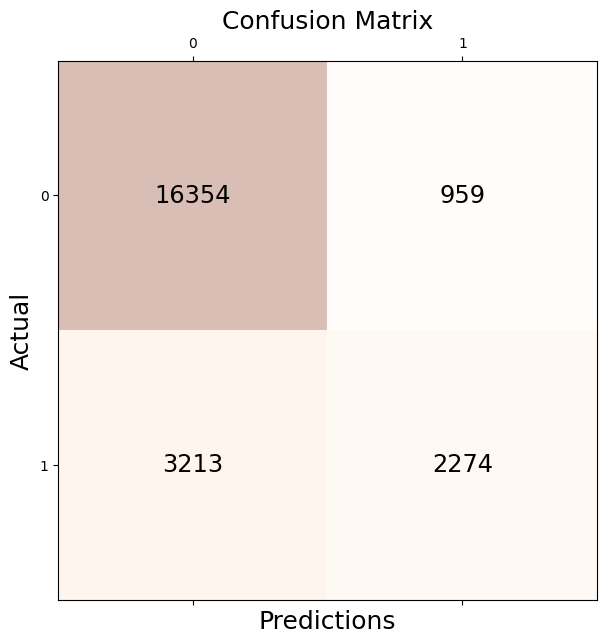

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     17313
           1       0.70      0.41      0.52      5487

    accuracy                           0.82     22800
   macro avg       0.77      0.68      0.70     22800
weighted avg       0.80      0.82      0.80     22800



In [37]:
y_train_pred_rf_tuned = rf_tuned.predict(X_train)
y_test_pred_rf_tuned = rf_tuned.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf_tuned):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_rf_tuned):.4f}")

conf_matrix_rf_tuned = confusion_matrix(y_test, y_test_pred_rf_tuned)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_rf_tuned, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_rf_tuned.shape[0]):
    for j in range(conf_matrix_rf_tuned.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_rf_tuned[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_rf_tuned))

In [38]:
print("Accuracy: ", (conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,1])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,1]+conf_matrix_rf_tuned[0,1]+conf_matrix_rf_tuned[1,0]) )
print("Precision of non-viral: ", (conf_matrix_rf_tuned[0,0])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[0,1]) )
print("Recall of non-viral: ", (conf_matrix_rf_tuned[0,0])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,0]) )

Accuracy:  0.8170175438596491
Precision of non-viral:  0.9446080979610697
Recall of non-viral:  0.8357949609035621


Run this cell if you have the tuned RandomForest Model in `/models` to load it into the notebook

In [48]:
rf_tuned = load("models/rf_tuned.joblib")


#### 4.2 RandomizedSearchCV on XGBoostClassifierModel

In [ ]:
from scipy.stats import uniform

In [67]:
param_dist = {
    "max_depth": randint(3, 11),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5),
    "learning_rate": uniform(0.01, 0.19),
    "gamma": uniform(0, 5.0),
}

In [68]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=1000,
    n_jobs=-1,
    random_state=42,
)


random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30, 
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42,
)


In [69]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[CV] END colsample_bytree=0.6872700594236812, gamma=4.75357153204958, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, subsample=0.5780093202212182; total time=  13.0s
[CV] END colsample_bytree=0.6872700594236812, gamma=4.75357153204958, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, subsample=0.5780093202212182; total time=  13.0s
[CV] END colsample_bytree=0.6872700594236812, gamma=4.75357153204958, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, subsample=0.5780093202212182; total time=  13.3s
[CV] END colsample_bytree=0.6872700594236812, gamma=4.75357153204958, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, subsample=0.5780093202212182; total time=  13.8s
[CV] END colsample_bytree=0.6872700594236812, gamma=4.75357153204958, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, subsample=0.5780093202212182; total time=  13.9s
[CV] END colsample_bytree=0.5779972601681014, gamma=0.29041806084

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x162dfa850>, 'gamma': <scipy.stats....t 0x1630f45f0>, 'learning_rate': <scipy.stats....t 0x162dfab50>, 'max_depth': <scipy.stats....t 0x164750e60>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the

In [70]:
print("Best Parameters: ", random_search.best_params_)
print("Best CV F1-Score: ", random_search.best_score_)
print("Best Estimator: ", random_search.best_estimator_)

Best Parameters:  {'colsample_bytree': np.float64(0.8059264473611898), 'gamma': np.float64(0.6974693032602092), 'learning_rate': np.float64(0.06550748322169145), 'max_depth': 10, 'min_child_weight': 3, 'subsample': np.float64(0.6912309956335814)}
Best CV F1-Score:  0.6516374383474262
Best Estimator:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8059264473611898), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.6974693032602092), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.06550748322169145), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              

In [71]:
best_params = random_search.best_params_

xgb_tuned = XGBClassifier(**best_params)

In [72]:
xgb_tuned.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,np.float64(0.8059264473611898)
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = x

Training Accuracy: 0.8114
Testing Accuracy: 0.7961
Precision: 0.7513
Recall: 0.2285
F1 Score: 0.3505


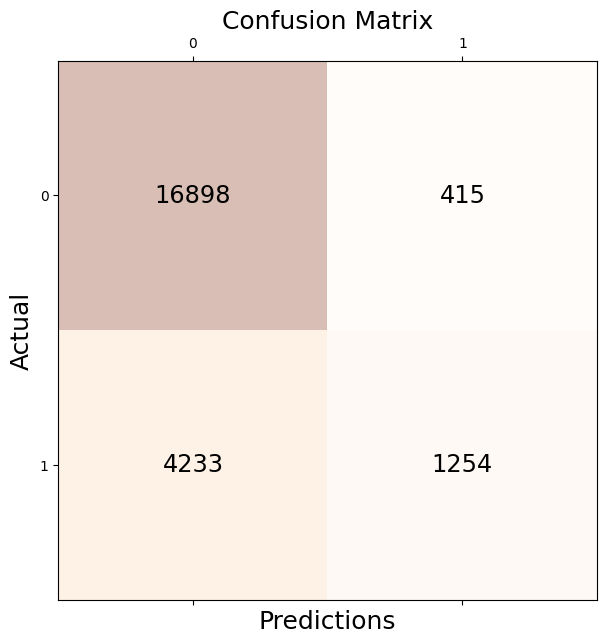

              precision    recall  f1-score   support

           0       0.80      0.98      0.88     17313
           1       0.75      0.23      0.35      5487

    accuracy                           0.80     22800
   macro avg       0.78      0.60      0.61     22800
weighted avg       0.79      0.80      0.75     22800



In [73]:
y_train_pred_xgb_tuned = xgb_tuned.predict(X_train)
y_test_pred_xgb_tuned = xgb_tuned.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_xgb_tuned):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_xgb_tuned):.4f}")

conf_matrix_xgb_tuned = confusion_matrix(y_test, y_test_pred_xgb_tuned)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_xgb_tuned, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_xgb_tuned.shape[0]):
    for j in range(conf_matrix_xgb_tuned.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_xgb_tuned[i, j], va='center', ha='center', size='xx-large')


plt.title('Confusion Matrix', fontsize=18)
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_xgb_tuned))


In [75]:
print("Accuracy: ", (conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,1])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,1]+conf_matrix_xgb_tuned[0,1]+conf_matrix_xgb_tuned[1,0]) )
print("Precision of non-viral: ", (conf_matrix_xgb_tuned[0,0])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[0,1]) )
print("Recall of non-viral: ", (conf_matrix_xgb_tuned[0,0])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,0]) )

Accuracy:  0.796140350877193
Precision of non-viral:  0.9760295731531219
Recall of non-viral:  0.7996781979082864


#### 4.3 GridSearchCV on XGBoostClassifierModel

In [76]:
param_grid = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "learning_rate": [0.05, 0.1],
    "gamma": [0, 2]
}

In [78]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=1000,
    n_jobs=-1,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

In [79]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=1.0; total time=  14.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=1.0; total time=  14.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=1.0; total time=  14.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=0.8; total time=  15.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=0.8; total time=  15.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=0.8; total time=  15.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, subsample=0.8; total time=  15.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 2], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [80]:
print("Best Parameters: ", grid_search.best_params_)
print("Best CV F1-Score: ", grid_search.best_score_)
print("Best Estimator: ", grid_search.best_estimator_)

Best Parameters:  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.8}
Best CV F1-Score:  0.6479486274351556
Best Estimator:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1,
              num_parallel_tree=None, ...)


In [81]:
best_params = grid_search.best_params_

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

Run this cell if you have the tuned XGBoostClassifier Model in `/models` to load it into the notebook

In [104]:
xgb_tuned = load("models/xgb_tuned.joblib")


Training Accuracy: 0.8179
Testing Accuracy: 0.8015
Precision: 0.7459
Recall: 0.2659
F1 Score: 0.3920


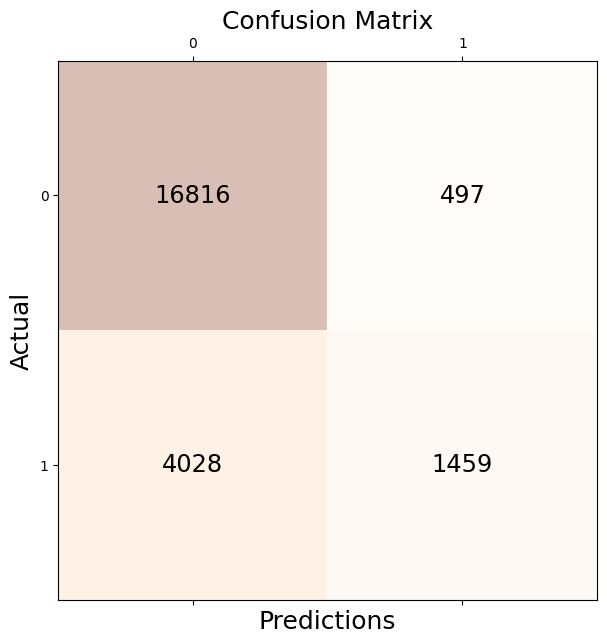

              precision    recall  f1-score   support

           0       0.81      0.97      0.88     17313
           1       0.75      0.27      0.39      5487

    accuracy                           0.80     22800
   macro avg       0.78      0.62      0.64     22800
weighted avg       0.79      0.80      0.76     22800



In [82]:
y_train_pred_xgb_tuned = xgb_tuned.predict(X_train)
y_test_pred_xgb_tuned = xgb_tuned.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_xgb_tuned):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_xgb_tuned):.4f}")

conf_matrix_xgb_tuned = confusion_matrix(y_test, y_test_pred_xgb_tuned)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_xgb_tuned, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_xgb_tuned.shape[0]):
    for j in range(conf_matrix_xgb_tuned.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_xgb_tuned[i, j], va='center', ha='center', size='xx-large')


plt.title('Confusion Matrix', fontsize=18)
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_xgb_tuned))


In [83]:
print("Accuracy: ", (conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,1])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,1]+conf_matrix_xgb_tuned[0,1]+conf_matrix_xgb_tuned[1,0]) )
print("Precision of non-viral: ", (conf_matrix_xgb_tuned[0,0])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[0,1]) )
print("Recall of non-viral: ", (conf_matrix_xgb_tuned[0,0])/(conf_matrix_xgb_tuned[0,0]+conf_matrix_xgb_tuned[1,0]) )

Accuracy:  0.8015350877192983
Precision of non-viral:  0.9712932478484376
Recall of non-viral:  0.8067549414699674


#### 4.4 GridSearchCV on RandomForest Model

In [93]:
# Create parameter grid based on the results of random search
param_grid = {
    'max_depth': [10, 20, 40],
    'min_samples_split': [2, 8, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', None],
    'n_estimators': [100, 500, 1000]
}

In [94]:
rf_base = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
)

# grid_search = GridSearchCV(
#     estimator=rf_base,
#     param_grid=param_grid,
#     scoring="f1",
#     cv=3,
#     n_jobs=-1,
#     verbose=2,
# )

In [86]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.1s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 1.3min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 1.3min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 1.3min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 2.6min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 2.6min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 2.6min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  18.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  18.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  19.2s
[CV] END max_depth=20, max_feature

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=  28.0s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=  27.0s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 2.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 2.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 2.1min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 2.1min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 2.1min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 4.3min
[CV] END max_depth=40, max_features=sqr

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
243 fits failed out of a total of 486.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
117 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 8, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [95]:
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2,
    error_score="raise",
)

In [96]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=   6.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=   6.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=   6.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  30.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  31.3s
[CV] END max_depth=10, max_features=sqrt

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=1000; total time= 1.0min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=500; total time=  34.7s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time= 1.1min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=500; total time=  36.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time= 1.1min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=500; total time=  35.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time=   7.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time=   7.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time=   7.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time= 1.2min
[CV] END max_depth=10, max_feature

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=500; total time=  42.5s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=500; total time=  42.6s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=500; total time=  41.7s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=100; total time=   8.4s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=100; total time=   8.8s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=100; total time=   8.7s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=500; total time=  41.3s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=500; total time=  41.8s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=1000; total time= 1.4min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=500; total time=  40.8s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   8.1s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   8.5s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   8.4s


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=1000; total time= 1.4min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=1000; total time= 1.4min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time= 1.4min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=500; total time=  41.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=500; total time=  42.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=500; total time=  42.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time= 1.4min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time= 1.4min
[CV] END max_depth=10, max_featu

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=2, n_estimators=500; total time=11.5min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=2, n_estimators=500; total time=11.4min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time= 2.5min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time= 2.4min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time= 2.4min
[CV] END max_depth=20, max_features=None, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=22.8min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=500; total time=11.6min
[CV] END max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=2, n_estimators=1000; total time=23.1min
[CV] END max_depth=20, max_features=N

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 4.6min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 4.6min
[CV] END max_depth=20, max_features=None, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time=22.0min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 2.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=500; total time= 2.3min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  29.0s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  28.3s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  28.7s
[CV] END max_depth=40, max_feature

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=1000; total time= 4.6min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=1000; total time= 4.5min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=500; total time= 2.3min


/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=500; total time= 2.3min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=500; total time= 2.3min
[CV] END max_depth=20, max_features=None, min_samples_leaf=5, min_samples_split=10, n_estimators=1000; total time=23.8min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100; total time=  27.0s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100; total time=  27.3s
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=1000; total time= 4.6min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=3, min_samples_split=8, n_estimators=1000; total time= 4.6min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100; total time=  27.6s
[CV] END max_depth=40, max_feature

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 8, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [97]:
print("Best Parameters: ", grid_search.best_params_)
print("Best CV F1-Score: ", grid_search.best_score_)
print("Best Estimator: ", grid_search.best_estimator_)

Best Parameters:  {'max_depth': 40, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score:  0.5092609910309286
Best Estimator:  RandomForestClassifier(max_depth=40, max_features=None, min_samples_leaf=3,
                       n_jobs=-1, random_state=42)


In [98]:
best_params = grid_search.best_params_

rf_tuned = RandomForestClassifier(**best_params)
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

Training Accuracy: 0.8998
Testing Accuracy: 0.8181
Precision: 0.7059
Recall: 0.4183
F1 Score: 0.5253


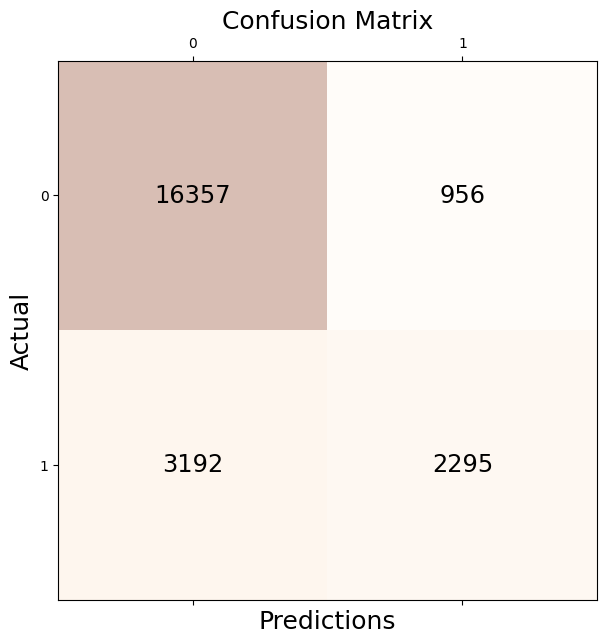

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     17313
           1       0.71      0.42      0.53      5487

    accuracy                           0.82     22800
   macro avg       0.77      0.68      0.71     22800
weighted avg       0.81      0.82      0.80     22800



In [99]:
y_train_pred_rf_tuned = rf_tuned.predict(X_train)
y_test_pred_rf_tuned = rf_tuned.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf_tuned):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_rf_tuned):.4f}")

conf_matrix_rf_tuned = confusion_matrix(y_test, y_test_pred_rf_tuned)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_rf_tuned, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix_rf_tuned.shape[0]):
    for j in range(conf_matrix_rf_tuned.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_rf_tuned[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_rf_tuned))

In [100]:
print("Accuracy: ", (conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,1])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,1]+conf_matrix_rf_tuned[0,1]+conf_matrix_rf_tuned[1,0]) )
print("Precision of non-viral: ", (conf_matrix_rf_tuned[0,0])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[0,1]) )
print("Recall of non-viral: ", (conf_matrix_rf_tuned[0,0])/(conf_matrix_rf_tuned[0,0]+conf_matrix_rf_tuned[1,0]) )

Accuracy:  0.8180701754385965
Precision of non-viral:  0.9447813781551435
Recall of non-viral:  0.8367179906900609


### 5. Feature Importance

#### 5.1 After GridSearchCV Tuning

In [106]:
print(rf_tuned)
print(xgb_tuned)

RandomForestClassifier(max_depth=40, max_features=None, min_samples_leaf=3)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [107]:
feature_name = X.columns

target_names = df['viral'].astype('category').unique().tolist()

In [108]:
rf_tuned_importances = rf_tuned.feature_importances_
xgb_tuned_importances = xgb_tuned.feature_importances_

Feature Importance of RandomForestModel after GridSearchCV

In [109]:
indicies = np.argsort(rf_tuned_importances)

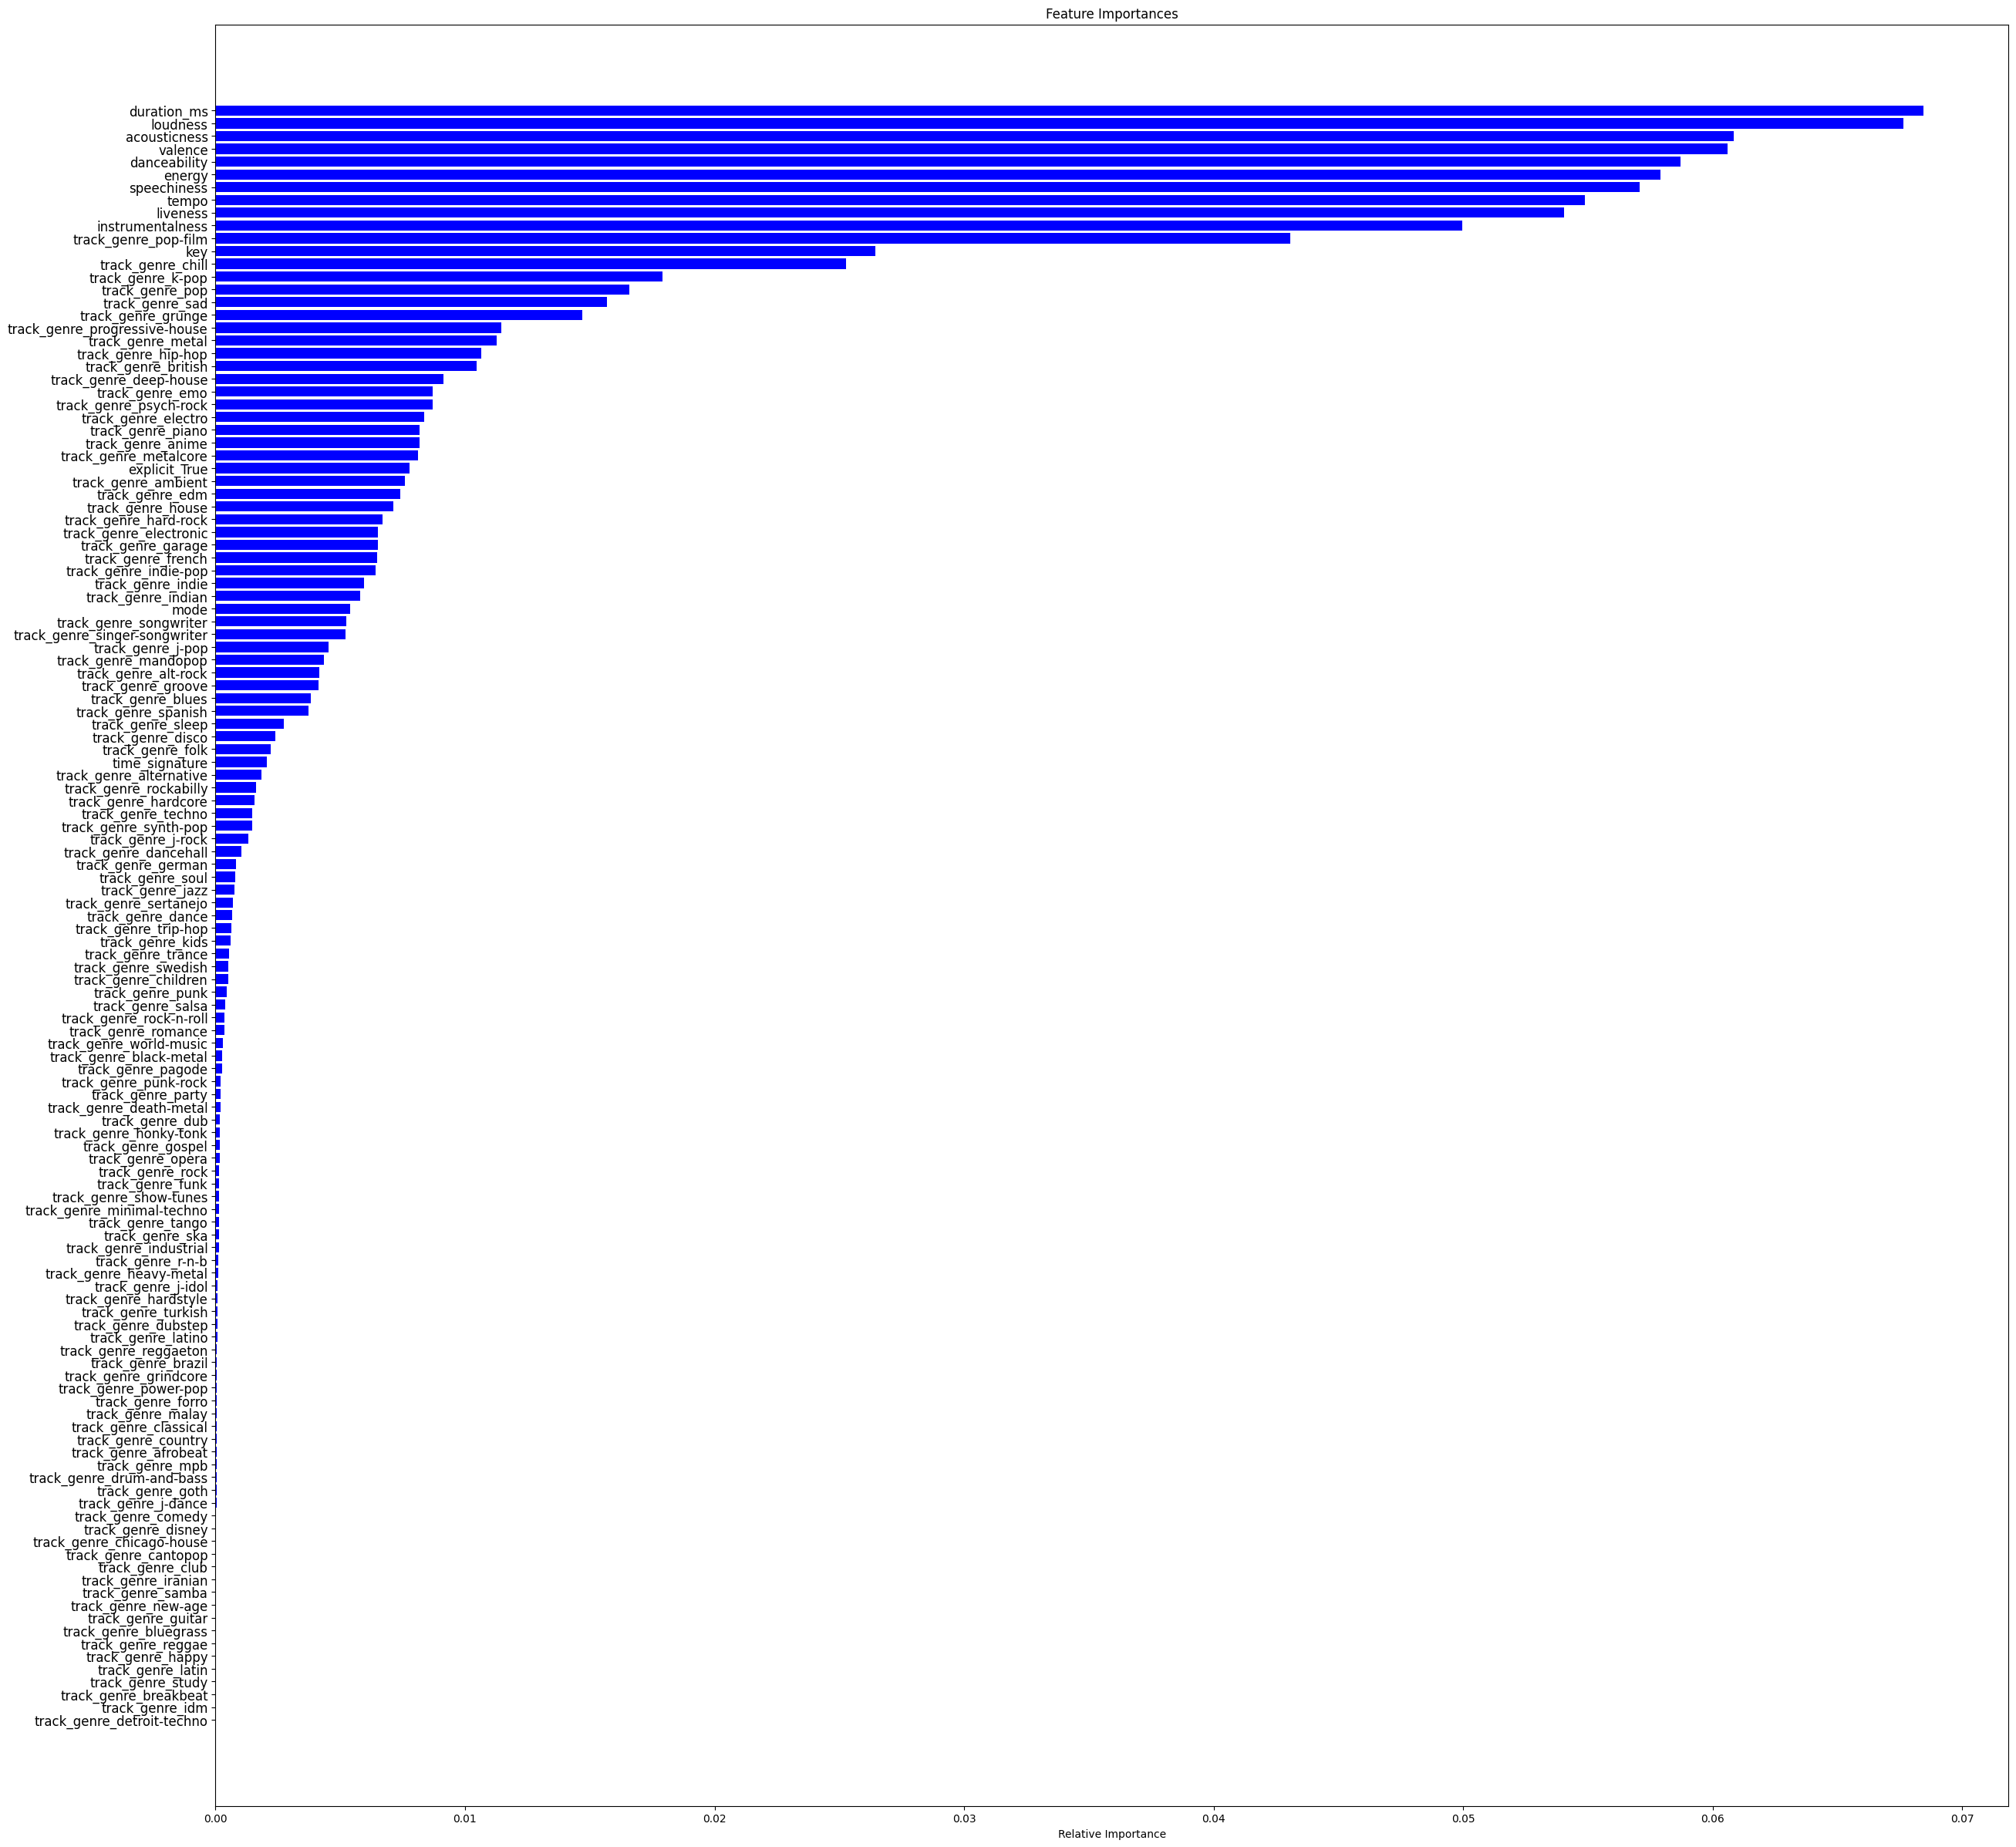

In [112]:
fig, ax = plt.subplots(figsize=(30, 30))
plt.title('Feature Importances')

plt.barh(range(len(indicies)), rf_tuned_importances[indicies], color='b', align='center')
plt.yticks(range(len(indicies)), [feature_name[i] for i in indicies], fontsize=12)
plt.xlabel('Relative Importance')
plt.show()

Feature Importance of XGBoostClassifierModel after GridSearchCV

In [113]:
indicies_xgb = np.argsort(xgb_tuned_importances)

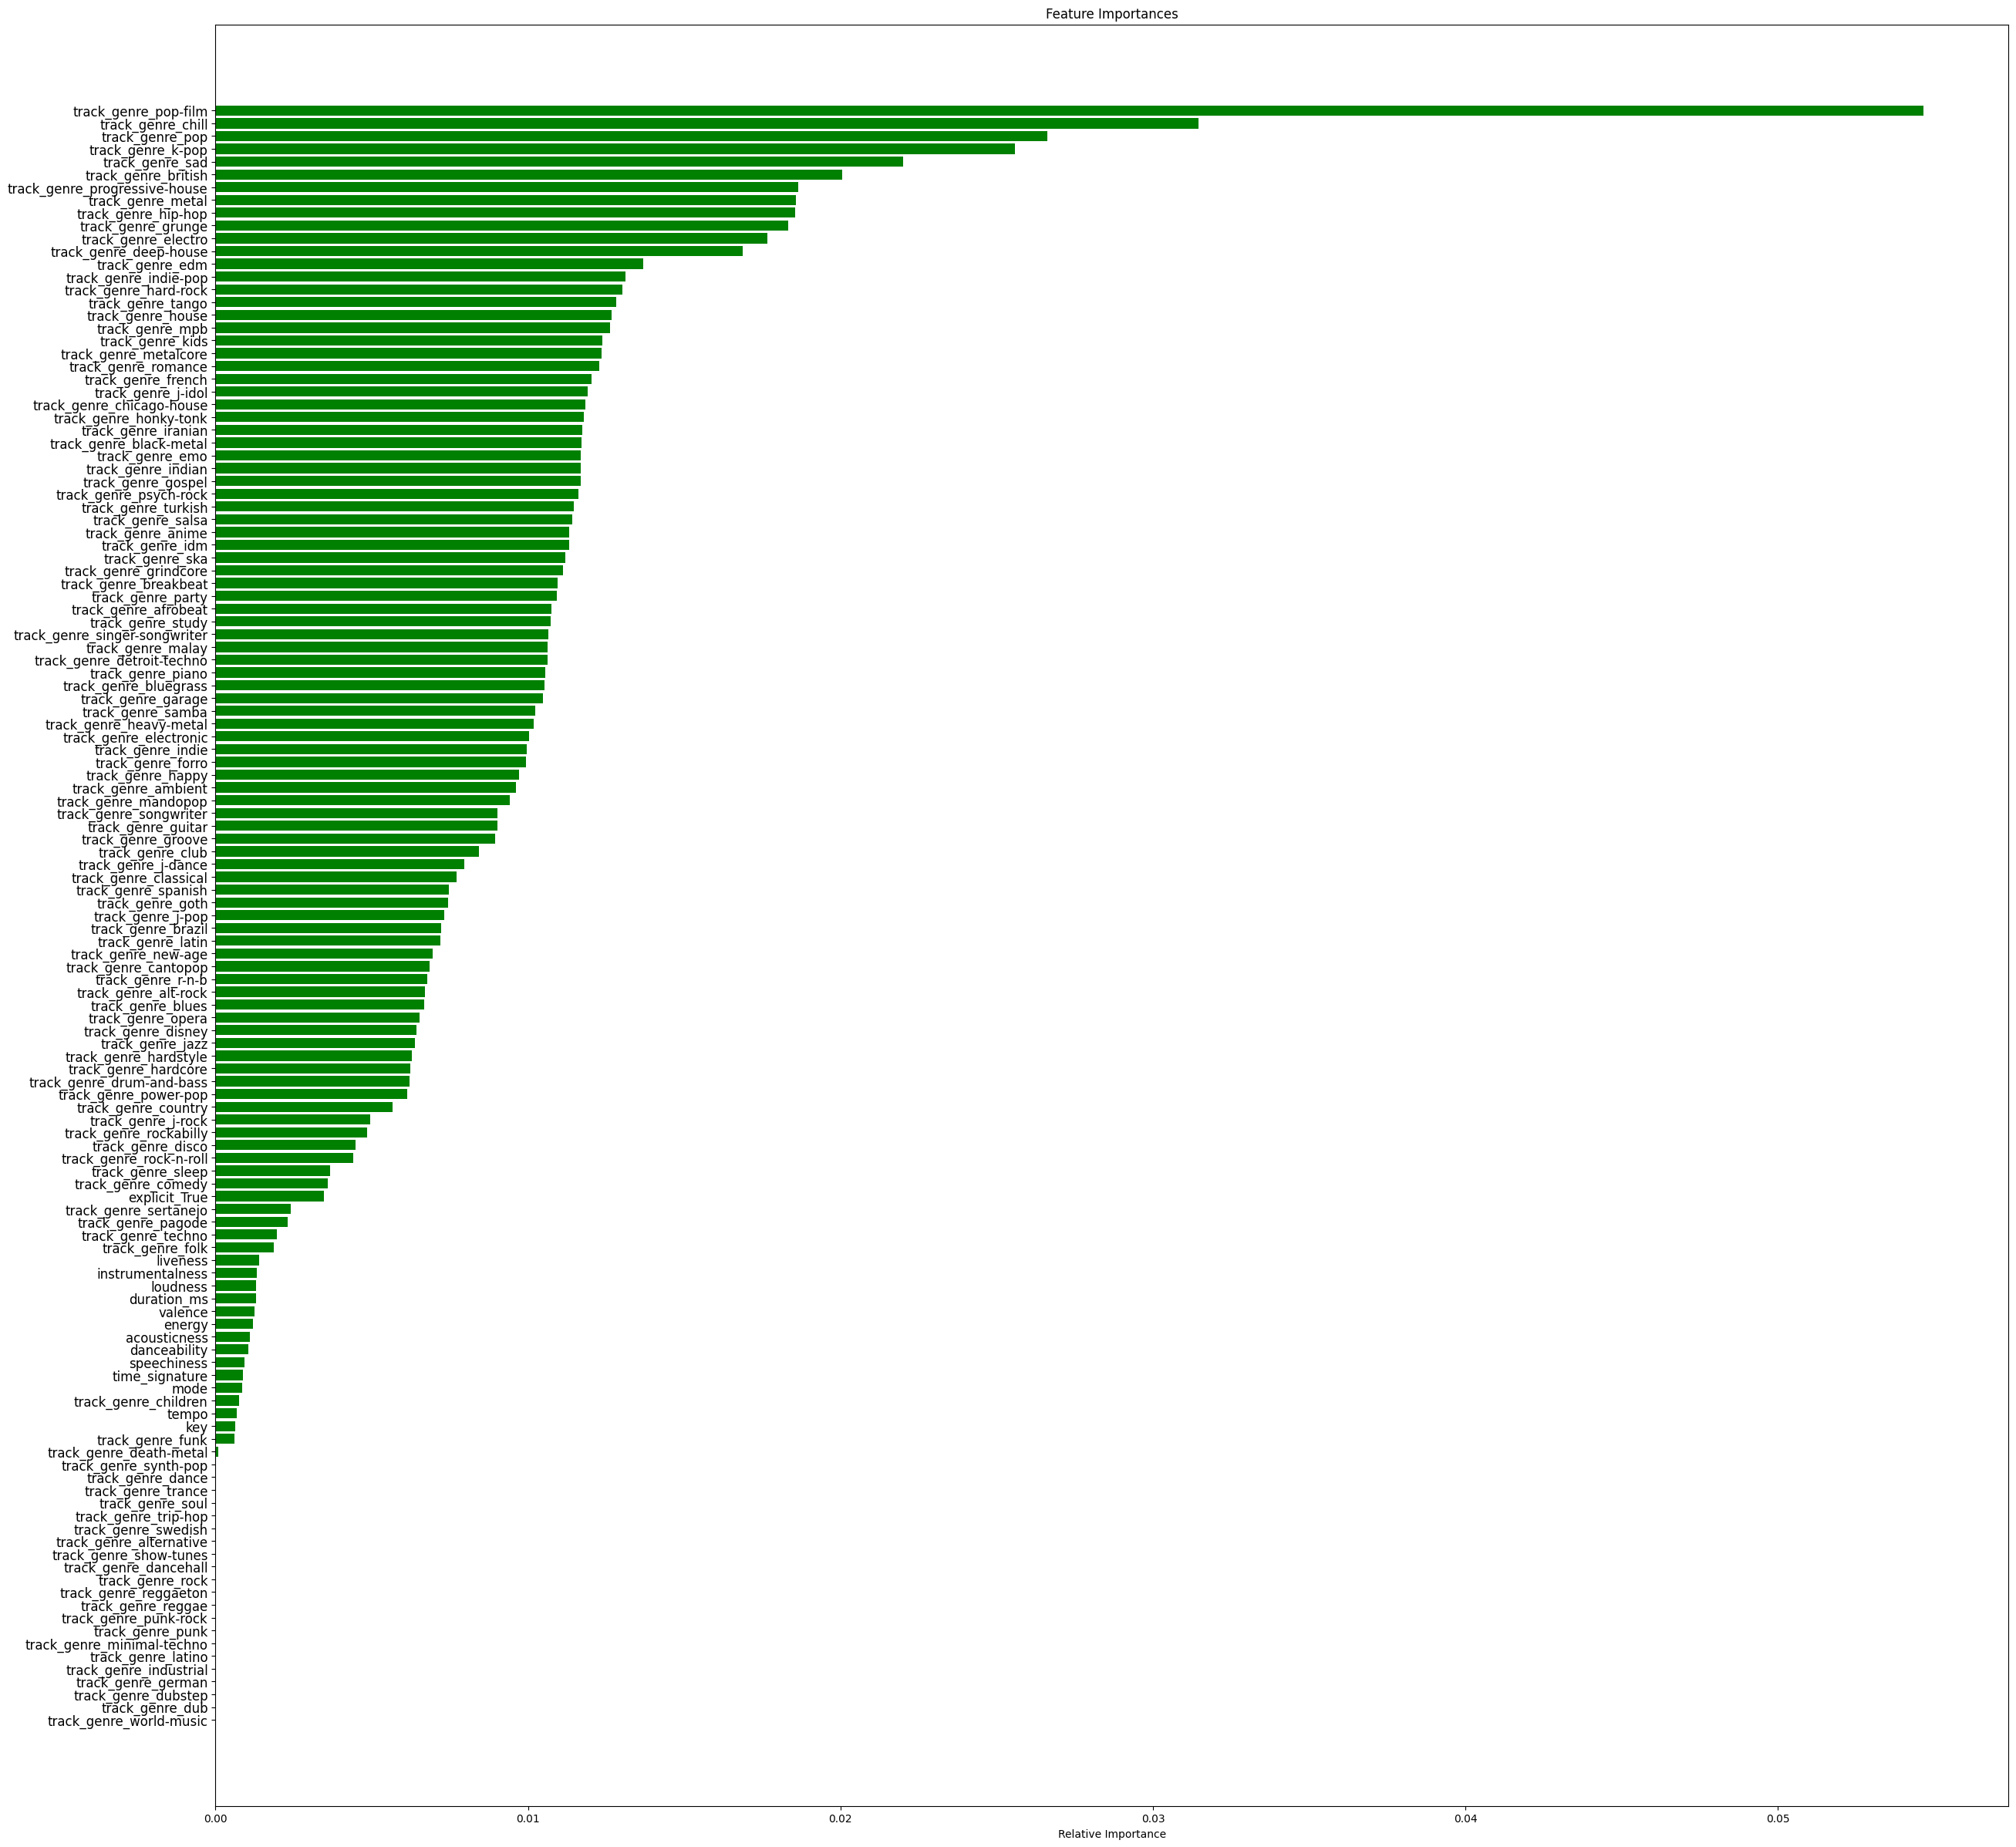

In [116]:
fig, ax = plt.subplots(figsize=(30, 30))
plt.title('Feature Importances')

plt.barh(range(len(indicies_xgb)), xgb_tuned_importances[indicies_xgb], color='g', align='center')
plt.yticks(range(len(indicies_xgb)), [feature_name[i] for i in indicies_xgb], fontsize=12)
plt.xlabel('Relative Importance')
plt.show()


